In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

from fpl_project.scripts import config
from fpl_project.scripts.data_utils.features_processing import FeatureEngineer

In [2]:
data = (pd.read_parquet(config.TIDY_DATA_PATH)).reset_index(drop=True)




In [3]:
data.columns

Index(['name', 'position', 'team', 'xP', 'assists', 'bonus', 'bps',
       'clean_sheets', 'creativity', 'element', 'xa', 'xg_involvements', 'xg',
       'xg_conceded', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals',
       'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves',
       'selected', 'starts', 'team_a_score', 'team_h_score', 'threat',
       'total_points', 'transfers_balance', 'transfers_in', 'transfers_out',
       'value', 'was_home', 'yellow_cards', 'season', 'gw', 'code',
       'xa_per_90', 'xg_involvements_per_90', 'xg_per_90',
       'xg_conceded_per_90', 'fixture_per_90'],
      dtype='str')

In [4]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float64)

    return df

In [5]:
data = numpy_dtypes(data)

In [6]:
data.dtypes.head()

name            str
position        str
team            str
xP          float64
assists     float64
dtype: object

In [7]:
data.columns = data.columns.str.lower()

In [8]:
#data.drop(columns=["understat", "date"], inplace=True)

In [9]:
data.head()

,name,position,team,xp,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90,fixture_per_90
0,Andy Lonergan,GK,Everton,1.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,315.0,0.0,0.0,0.0,0.0,2023-04-22T14:00:00,0.0,7.0,0.0,0.0,0.0,0.0,32.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,False,0.0,2223.0,32.0,11948.0,0.0,0.0,0.0,0.0,0.0
1,Andy Lonergan,GK,Everton,-0.5,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,322.0,0.0,0.0,0.0,0.0,2023-04-27T18:45:00,0.0,15.0,0.0,0.0,0.0,0.0,33.0,0.0,1.932986e-07,0.0,4.0,1.0,0.0,0.0,17.0,18.0,1.0,4.0,True,0.0,2223.0,33.0,11948.0,0.0,0.0,0.0,0.0,0.0
2,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,337.0,0.0,0.0,0.0,0.0,2023-05-01T19:00:00,0.0,10.0,0.0,0.0,0.0,0.0,34.0,0.0,3.452826e-07,0.0,2.0,2.0,0.0,0.0,19.0,25.0,6.0,4.0,False,0.0,2223.0,34.0,11948.0,0.0,0.0,0.0,0.0,0.0
3,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,342.0,0.0,0.0,0.0,0.0,2023-05-08T16:30:00,0.0,5.0,0.0,0.0,0.0,0.0,35.0,0.0,6.484797e-07,0.0,5.0,1.0,0.0,0.0,11.0,32.0,21.0,4.0,False,0.0,2223.0,35.0,11948.0,0.0,0.0,0.0,0.0,0.0
4,Andy Lonergan,GK,Everton,0.0,0.0,0.0,0.0,0.0,0.0,760.0,0.0,0.0,0.0,0.0,356.0,0.0,0.0,0.0,0.0,2023-05-14T13:00:00,0.0,13.0,0.0,0.0,0.0,0.0,36.0,0.0,6.562414e-07,0.0,3.0,0.0,0.0,0.0,-3.0,22.0,25.0,4.0,True,0.0,2223.0,36.0,11948.0,0.0,0.0,0.0,0.0,0.0


In [10]:
data.isna().sum().sum()

np.int64(0)

In [11]:
data["transfers_trend"] = (data.transfers_balance / data.selected).replace([np.inf, -np.inf], np.nan).fillna(0)

In [12]:
data.shape

(105866, 49)

In [13]:
target = ["total_points"]

id_cols = ["name", "element", "kickoff_time", "gw", "code", "season"]

static_cols = ["position", "was_home", "starts"]

fpl_cols = ["bonus", "bps", "ict_index", "influence", "value", "threat"] + list(set([c for c in data.columns if "transfers" in c or "selected" in c]))

perf_cols = list(set([c for c in data.columns if c not in target + id_cols + static_cols + fpl_cols]))

In [14]:
data.shape[1], len(target + id_cols + static_cols + fpl_cols + perf_cols)

(49, 49)

In [15]:
[c for c in target + id_cols + static_cols + fpl_cols + perf_cols if c not in data.columns]

[]

In [16]:
feature_eng = FeatureEngineer(df=data)
LAG_SIZE = [1, 2, 3, 5]
WINDOW_SIZE = [3, 5, 8]
STD_SIZE = WINDOW_SIZE
data_lag = feature_eng.features_integration(lag_size=LAG_SIZE, window_size=WINDOW_SIZE, std_size=STD_SIZE)

In [17]:
data_lag.head()

,position,was_home,selected,kickoff_time,season,transfers_out,code,transfers_in,transfers_balance,transfers_trend,element,name,gw,value,total_points,bonus_ema_3,bps_ema_3,ict_index_ema_3,influence_ema_3,value_ema_3,threat_ema_3,selected_ema_3,transfers_out_ema_3,transfers_balance_ema_3,transfers_in_ema_3,transfers_trend_ema_3,yellow_cards_ema_3,xg_conceded_per_90_ema_3,clean_sheets_ema_3,minutes_ema_3,xg_involvements_per_90_ema_3,xg_per_90_ema_3,xa_per_90_ema_3,own_goals_ema_3,assists_ema_3,xg_ema_3,saves_ema_3,penalties_saved_ema_3,xp_ema_3,penalties_missed_ema_3,goals_scored_ema_3,team_h_score_ema_3,xa_ema_3,xg_involvements_ema_3,team_a_score_ema_3,goals_conceded_ema_3,creativity_ema_3,xg_conceded_ema_3,red_cards_ema_3,total_points_ema_3,bonus_ema_5,bps_ema_5,ict_index_ema_5,influence_ema_5,value_ema_5,threat_ema_5,selected_ema_5,transfers_out_ema_5,transfers_balance_ema_5,transfers_in_ema_5,transfers_trend_ema_5,yellow_cards_ema_5,xg_conceded_per_90_ema_5,clean_sheets_ema_5,minutes_ema_5,xg_involvements_per_90_ema_5,xg_per_90_ema_5,xa_per_90_ema_5,own_goals_ema_5,assists_ema_5,xg_ema_5,saves_ema_5,penalties_saved_ema_5,xp_ema_5,penalties_missed_ema_5,goals_scored_ema_5,team_h_score_ema_5,xa_ema_5,xg_involvements_ema_5,team_a_score_ema_5,goals_conceded_ema_5,creativity_ema_5,xg_conceded_ema_5,red_cards_ema_5,total_points_ema_5,bonus_ema_8,bps_ema_8,ict_index_ema_8,influence_ema_8,value_ema_8,threat_ema_8,selected_ema_8,transfers_out_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_trend_ema_8,yellow_cards_ema_8,xg_conceded_per_90_ema_8,clean_sheets_ema_8,minutes_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xa_per_90_ema_8,own_goals_ema_8,assists_ema_8,xg_ema_8,saves_ema_8,penalties_saved_ema_8,xp_ema_8,penalties_missed_ema_8,goals_scored_ema_8,team_h_score_ema_8,xa_ema_8,xg_involvements_ema_8,team_a_score_ema_8,goals_conceded_ema_8,creativity_ema_8,xg_conceded_ema_8,red_cards_ema_8,total_points_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,value_lagged_1,threat_lagged_1,selected_lagged_1,transfers_out_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_trend_lagged_1,yellow_cards_lagged_1,xg_conceded_per_90_lagged_1,clean_sheets_lagged_1,minutes_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xa_per_90_lagged_1,own_goals_lagged_1,assists_lagged_1,xg_lagged_1,saves_lagged_1,penalties_saved_lagged_1,xp_lagged_1,penalties_missed_lagged_1,goals_scored_lagged_1,team_h_score_lagged_1,xa_lagged_1,xg_involvements_lagged_1,team_a_score_lagged_1,goals_conceded_lagged_1,creativity_lagged_1,xg_conceded_lagged_1,red_cards_lagged_1,total_points_lagged_1,bonus_lagged_2,bps_lagged_2,ict_index_lagged_2,influence_lagged_2,value_lagged_2,threat_lagged_2,selected_lagged_2,transfers_out_lagged_2,transfers_balance_lagged_2,transfers_in_lagged_2,transfers_trend_lagged_2,yellow_cards_lagged_2,xg_conceded_per_90_lagged_2,clean_sheets_lagged_2,minutes_lagged_2,xg_involvements_per_90_lagged_2,xg_per_90_lagged_2,xa_per_90_lagged_2,own_goals_lagged_2,assists_lagged_2,xg_lagged_2,saves_lagged_2,penalties_saved_lagged_2,xp_lagged_2,penalties_missed_lagged_2,goals_scored_lagged_2,team_h_score_lagged_2,xa_lagged_2,xg_involvements_lagged_2,team_a_score_lagged_2,goals_conceded_lagged_2,creativity_lagged_2,xg_conceded_lagged_2,red_cards_lagged_2,total_points_lagged_2,bonus_lagged_3,bps_lagged_3,ict_index_lagged_3,influence_lagged_3,value_lagged_3,threat_lagged_3,selected_lagged_3,transfers_out_lagged_3,transfers_balance_lagged_3,transfers_in_lagged_3,transfers_trend_lagged_3,yellow_cards_lagged_3,xg_conceded_per_90_lagged_3,clean_sheets_lagged_3,minutes_lagged_3,xg_involvements_per_90_lagged_3,xg_per_90_lagged_3,xa_per_90_lagged_3,own_goals_lagged_3,assists_lagged_3,xg_lagged_3,saves_lagged_3,penalties_saved_lagged_3,xp_lagged_3,penalties_missed_lagged_3,goals_scored_lagged_3,team_h_score_lagged_3,xa_lagged_3,xg_involvements_lagged_3,team_a_score_lagged_3,goals_conceded_lagged_3,creativity_l

In [18]:
data_lag.isna().sum().sum()

np.int64(0)

In [19]:
data_lag.shape

(105866, 365)

In [20]:
len(data_lag.columns), len(set(data_lag.columns))

(365, 365)

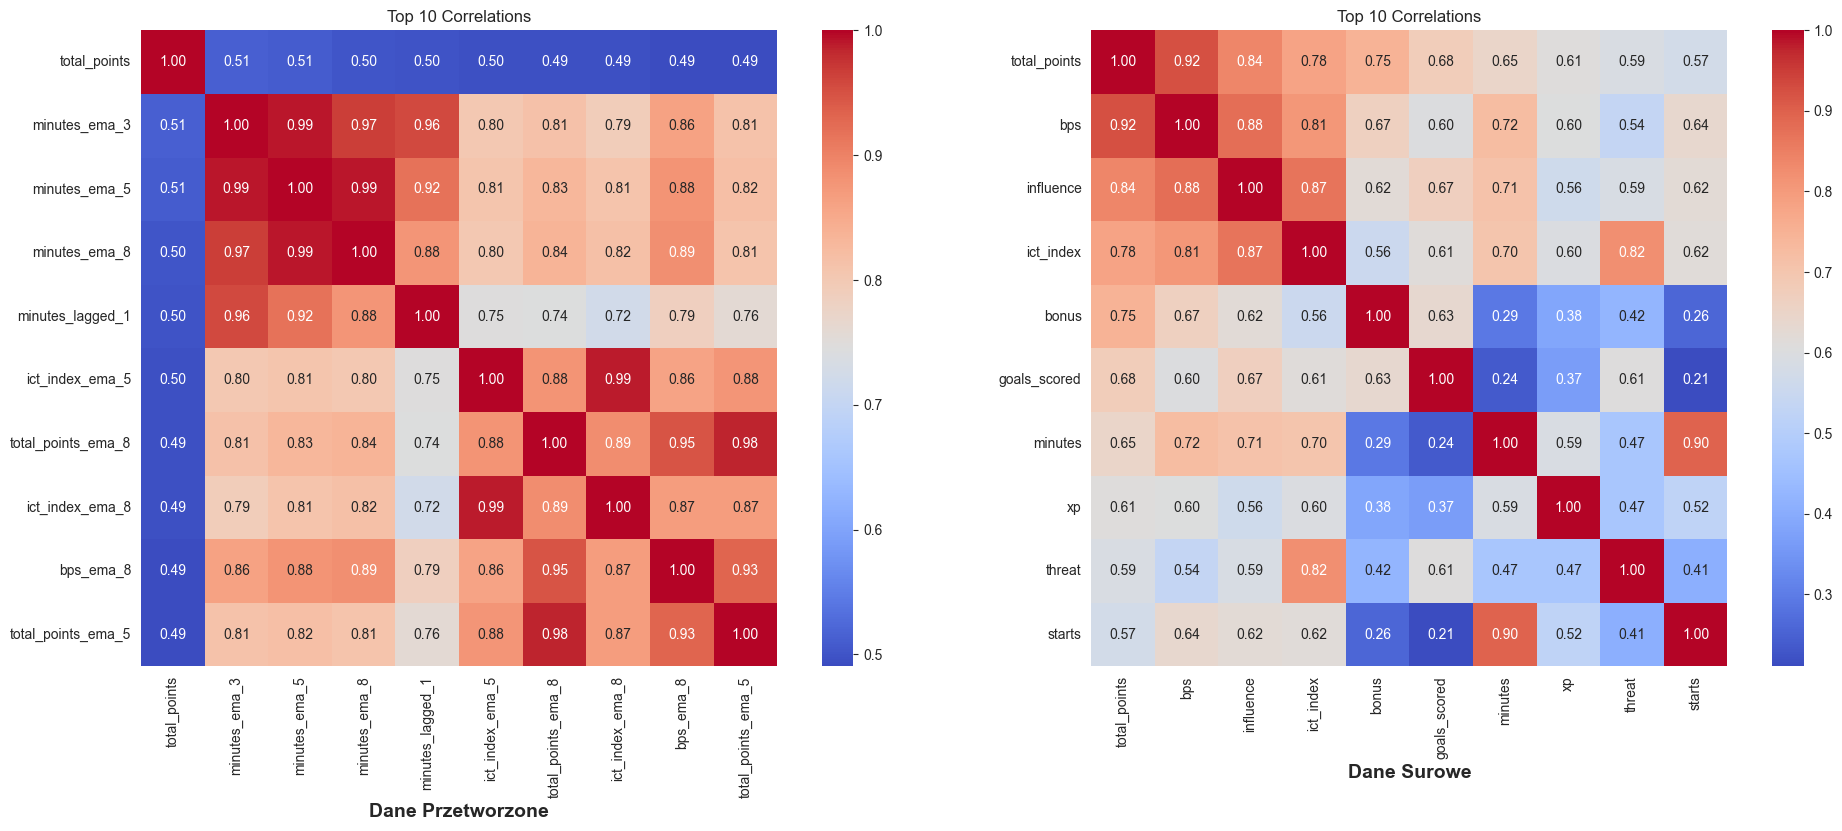

In [21]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr()["total_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lag, data], ["Dane Przetworzone", "Dane Surowe"])

In [22]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.drop(columns=["total_points"], errors="ignore").select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [23]:
pairs_list = over_corr_pairs(data_lag, threshold=0.9)
pairs = pd.DataFrame(pairs_list)

if not pairs.empty:
    cols_to_drop = pairs[1].unique()
    data_lag.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    print(f"Usunięto {len(cols_to_drop)} silnie skorelowanych kolumn.")
else:
    print("Nie znaleziono silnie skorelowanych kolumn do usunięcia.")

Usunięto 103 silnie skorelowanych kolumn.


In [24]:
data_lag.shape

(105866, 262)

In [25]:
data_lag.to_parquet(config.FPL_DATA_PATH,
                index=False)